<a href="https://colab.research.google.com/github/carolsworld/NX_TSC/blob/main/NX_TSC_sktime_LSTMFCNClassifier_5Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Demonstration of using datasets generated multivariate time series data from NX MCD simulation software for developing multi-class Time Series Classification Model for *Threat Detection* using *Long Short Term Memory Fully Convolutional Network (LSTM-FCN)* in sktime (deep learning) library**

# Background

We have identified 5 different scenarios in the NX scene. It could be a normal scenarios or threat scenarios.

For each scenario, we have carried out 10 simulation runs (i.e. 10 instances). Therefore, there are tototally 50 simulation instances in the csv dataset. Each simulation run has 60 second of simulation.

During the simulation run, we used the export function of NX MCD to collect data. With a sampling rate of 0.03 second, in 1 minute of simulation, each instance contain 2000 timepoints (timepoints from value '0' to value '1999'). Therefore, the number of row in the csv dataset is 2000 * 50 = 100,000 rows.


The scenario (being the label (y) to be predicted) include:

*   Label #0 - 'Normal_NoIntervention': Baseline operation without intervention.
*   Label #1 - 'Conveyor_SpeedManipulation':Speed forcibly reduced from standard (e.g., 300 to 50, or 50 to 10).
*   Label #2 - 'Gripper_SuctionForceRelease': Suction signal changed from 1 (hold) to 0 (release).
*   Label #3 - 'Gripper_ZAxisDirectionManipulation': Reverses Z-axis movement by forcing -400 (downward) instead of +400 (upward), and vice versa.
*   Label #4 - 'Gripper_RotationDeviation': Rotation angle forced to inappropriate value (e.g., 0° to 360°).

In [1]:
# Turn on GPU T4

# Runtime > Change runtime type

gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Sun Apr  6 19:32:12 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Step 1 - Upload dataset (csv file)

In [2]:
# Upload your csv file and check the number of rows and columns in the pandas dataframe
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()

filename = next(iter(uploaded))

df = pd.read_csv(io.BytesIO(uploaded['NXdata_5ScenariosaddFeatures.csv']))

print("The number of rows and columns in the csv file: ", df.shape)

Saving NXdata_5ScenariosaddFeatures.csv to NXdata_5ScenariosaddFeatures.csv
The number of rows and columns in the csv file:  (100000, 8)


50 instances with 2000 timepoints for each instance, expected number of row is 100,000.

In [3]:
# Display the first few rows of the dataframe to check file format
print(df.head())

   instance  timepoint  MCD_GetBoxDone-value  GetBox_signal-value  \
0         1          0                     1                    1   
1         1          1                     1                    1   
2         1          2                     1                    1   
3         1          3                     1                    1   
4         1          4                     1                    1   

   Conveyor_Speed_AnyAbnormalFlag  Gripper_Z_Speed_CombinedAnomalyFlag  \
0                               0                                    0   
1                               0                                    0   
2                               0                                    0   
3                               0                                    0   
4                               0                                    0   

   RotatePosition_CombinedAnomalyFlag  label  
0                                   0      0  
1                                   0      0  

Regarding the columns on the dataset:
*   'instance' is instance identifier. There are 50 instance in this dataset.
*   'timepoints' is time series index for each instance. Every instance has 2000 timepoints (from value '0' to value '1999').
*    other than the above two columns and the 'label' column, the rest of the columns are the raw data from NX MCD and features to learn
*   'label' contains the labels of the instance, with value ranged from 0 to 4


# Step 2 - Dataset preprocessing

In [4]:
import numpy as np

# Set the index for multi-indexing
df = df.set_index(['instance', 'timepoint'])

# Sort the dataframe if not already sorted
df.sort_index(inplace=True)

In [5]:
# Calculate the number of instances and timepoints
num_instances = df.index.get_level_values(0).nunique()
num_timepoints = df.index.get_level_values(1).nunique()

In [6]:
print("Number of instances:", num_instances)
print("Number of timepoints:", num_timepoints)

Number of instances: 50
Number of timepoints: 2000


In [7]:
# Drop the 'label' column to get the features
X_features = df.drop(columns='label')

In [8]:
X_features

MCD_GetBoxDone-value  GetBox_signal-value  \
instance timepoint                                              
1        0                             1                    1   
         1                             1                    1   
         2                             1                    1   
         3                             1                    1   
         4                             1                    1   
...                                  ...                  ...   
50       1995                          1                    1   
         1996                          1                    1   
         1997                          1                    1   
         1998                          1                    1   
         1999                          1                    1   

                    Conveyor_Speed_AnyAbnormalFlag  \
instance timepoint                                   
1        0                                       0   
         1                                       0   
         2                                       0   
         3                                       0   
         4                                       0   
...                                            ...   
50       1995                                    0   
         1996                                    0   
         1997                                    0   
         1998                                    0   
         1999                                    0   

                    Gripper_Z_Speed_CombinedAnomalyFlag  \
instance timepoint                                        
1        0                                            0   
         1                                            0   
         2                                            0   
         3                                            0   
         4                                            0   
...                                                 ...   
50       1995                                         0   
         1996                                         0   
         1997                                         0   
         1998                                         0   
         1999                                         0   

                    RotatePosition_CombinedAnomalyFlag  
instance timepoint                                      
1        0                                           0  
         1                                           0  
         2                                           0  
         3                                           0  
         4                                           0  
...                                                ...  
50       1995                                        0  
         1996                                        0  
         1997                                        0  
         1998                                        0  
         1999                                        0  

[100000 rows x 5 columns]

In [9]:
# Print the shapes
print("Shape before reshaping:", X_features.shape)
print("Total expected size:", num_instances * 5 * num_timepoints)

Shape before reshaping: (100000, 5)
Total expected size: 500000


In [10]:
# Split the data into features (X) and labels (y):
# For this demonstration, there are 8 variables.
X = df.drop(columns='label').to_numpy().reshape(-1, 5, df.index.levels[1].size)
y = df['label'].to_numpy()

In [11]:
# Ensure labels are unique per instance and not per time point
# Reshape features (X) into a 3D numpy array
_, idx = np.unique(df.index.get_level_values(0), return_index=True)
y = y[idx]

In [12]:
X

array([[[1, 1, 0, ..., 0, 0, 0],
        [1, 1, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [1, 1, 0, ..., 0, 0, 1],
        [1, 1, 0, ..., 0, 0, 0],
        [1, 1, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [1, 1, 0, ..., 0, 0, 0],
        [1, 1, 0, ..., 0, 0, 0],
        [1, 1, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [1, 1, 0, ..., 0, 0, 1],
        [1, 1, 0, ..., 0, 0, 1],
        [1, 1, 0, ..., 0, 0, 0],
        [1, 1, 0, ..

In [13]:
X.shape

(50, 5, 2000)

X is 3D array and should have the shape [number of samples, number of variables, sequence length].

Each of the 50 instances is a 2D array of 7 variables over 2000 timepoints

In [14]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4])

In [15]:
y.shape

(50,)

y is 1D numpy array with the shape [number of samples].

In [16]:
# Split the data into a training set and a test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=3, stratify=y)


In [17]:
X_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 1, 0, 0],
        [0, 0, 1, ..., 1, 0, 0],
        [1, 1, 1, ..., 1, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [1, 1, 0, ..., 0, 0, 0],
        [1, 1, 0, ..., 0, 0, 0],
        [1, 1, 0, ..., 0, 0, 0],
        [1, 1, 0, ..., 0, 0, 0]],

       [[0, 0, 1, ..., 0, 0, 0],
        [0, 1, 0, ..., 0, 0, 0],
        [1, 1, 0, ..., 0, 0, 0],
        [1, 1, 0, ..., 0, 0, 0],
        [1, 1, 0, ..., 0, 0, 0]],

       ...,

       [[1, 1, 0, ..., 0, 0, 0],
        [1, 1, 0, ..., 1, 0, 0],
        [0, 0, 1, ..., 1, 0, 0],
        [0, 0, 1, ..., 1, 0, 0],
        [0, 0, 1, ..., 1, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [1, 1, 0, ..., 0, 0, 0],
        [1, 1, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[1, 1, 0, ..., 0, 0, 0],
        [1, 1, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..

In [18]:
X_test

array([[[1, 1, 0, ..., 0, 0, 0],
        [1, 1, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[1, 1, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 1, 0],
        [0, 0, 0, ..., 0, 1, 0]],

       ...,

       [[1, 1, 0, ..., 0, 1, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 1, 0],
        [0, 0, 0, ..., 0, 1, 0],
        [0, 0, 0, ..., 0, 1, 0]],

       [[1, 1, 0, ..., 1, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 0, ..., 1, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [0, 0, 0, ..., 1, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [1, 1, 0, ..., 0, 0, 0],
        [1, 1, 0, ..., 0, 0, 0],
        [1, 0, 0, ..., 0, 0, 0],
        [1, 1, 0, ..

In [19]:
y_train

array([1, 2, 1, 1, 0, 2, 3, 1, 3, 4, 2, 4, 3, 4, 0, 3, 4, 4, 2, 0, 0, 1,
       1, 3, 3, 3, 4, 2, 0, 2, 4, 0, 1, 2, 0])

In [20]:
y_test

array([0, 2, 3, 3, 1, 0, 1, 4, 4, 2, 0, 2, 3, 1, 4])

# Step 3 - Train the model

In [21]:
# Install the sktime library
!pip install sktime
import sktime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.7/142.7 kB 14.9 MB/s eta 0:00:00


In [22]:
# Check in memory type is correct for label y
from sktime.datatypes import check_is_mtype
check_is_mtype(y, mtype="np.ndarray", return_metadata=True)

(True,
 '',
 {'is_empty': False,
  'is_univariate': True,
  'n_features': 1,
  'feature_names': [0],
  'dtypekind_dfip': [<DtypeKind.FLOAT: 2>],
  'feature_kind': [<DtypeKind.FLOAT: 2>],
  'is_equally_spaced': True,
  'has_nans': np.False_,
  'mtype': 'np.ndarray',
  'scitype': 'Series'})

In [23]:
import numpy as np
import seaborn as sns

from sktime.classification.deep_learning.lstmfcn import LSTMFCNClassifier

sns.set_style("whitegrid")

In [24]:
# Initialize the LSTMFCNClassifier
classifier = LSTMFCNClassifier()

In [25]:
# Fit the classifier on the training data
classifier.fit(X_train, y_train)

LSTMFCNClassifier()

# Step 4 - Prediction and Performance Analysis

In [26]:
# Predict the labels for the test set
y_pred = classifier.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step


In [27]:
# Calculate accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8


In [28]:
# Check classification_report
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, output_dict=True)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.75      1.00      0.86         3
           2       0.75      1.00      0.86         3
           3       0.75      1.00      0.86         3
           4       1.00      0.33      0.50         3

    accuracy                           0.80        15
   macro avg       0.85      0.80      0.77        15
weighted avg       0.85      0.80      0.77        15



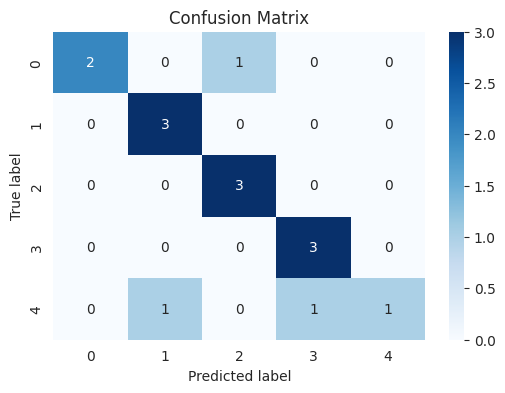

In [29]:
# Check confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap=plt.cm.Blues)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()


In [30]:
import pandas as pd

# Create a DataFrame showing instance index, true label, and predicted label
results_df = pd.DataFrame({
    'Instance Index': list(range(len(y_test))),
    'True Label': y_test,
    'Predicted Label': y_pred
})

# Show mismatches only
mismatches = results_df[results_df['True Label'] != results_df['Predicted Label']]

# Display the full or mismatched results
from IPython.display import display
display(mismatches)         # Only mismatches

,Instance Index,True Label,Predicted Label
5,5,0,2
7,7,4,1
8,8,4,3


The scenario (being the label (y) to be predicted) include:

*   Label #0 - 'Normal_NoIntervention': Baseline operation without intervention.
*   Label #1 - 'Conveyor_SpeedManipulation':Speed forcibly reduced from standard (e.g., 300 to 50, or 50 to 10).
*   Label #2 - 'Gripper_SuctionForceRelease': Suction signal changed from 1 (hold) to 0 (release).
*   Label #3 - 'Gripper_ZAxisDirectionManipulation': Reverses Z-axis movement by forcing -400 (downward) instead of +400 (upward), and vice versa.
*   Label #4 - 'Gripper_RotationDeviation': Rotation angle forced to inappropriate value (e.g., 0° to 360°).

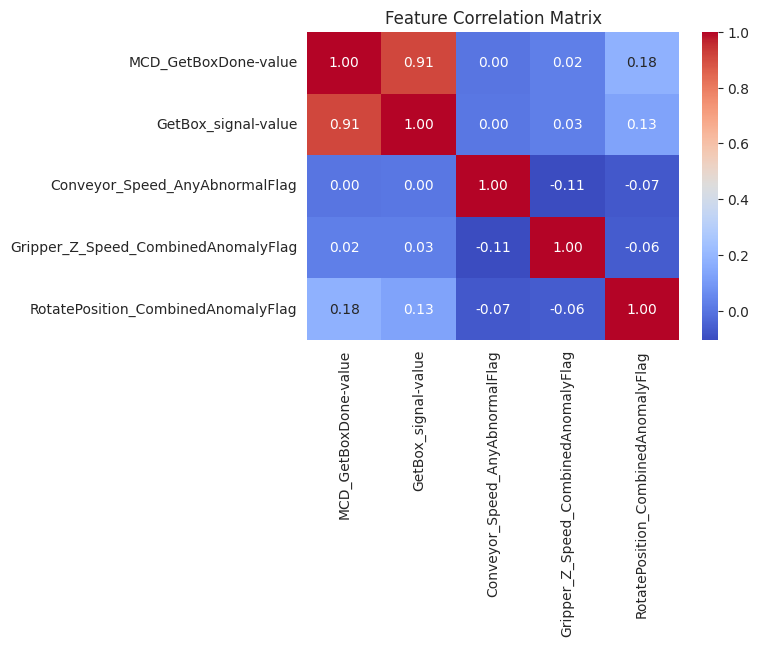

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

feature_cols = df.drop(columns=['instance', 'timepoint', 'label'], errors='ignore')
corr = feature_cols.corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

# Step 5 - Save trained model and evaluate on unseen multi-vector attack data

In [32]:
# Save model using pickle
import pickle

model_filename = '/content/NX_LSTMFCN.pkl'

with open(model_filename, 'wb') as file:
    pickle.dump(classifier, file)

Reminder: download the model from Google Colab file directory.

In [33]:
# Import untrained cases to evaluate the capability to identify mulit-vector attack
uploaded = files.upload()

filename = next(iter(uploaded))

df_unknown = pd.read_csv(io.BytesIO(uploaded['NXdata_UnknowncasesaddFeatures.csv']))


print("Shape of uploaded file:", df_unknown.shape)
df_unknown.head()

Saving NXdata_UnknowncasesaddFeatures.csv to NXdata_UnknowncasesaddFeatures.csv
Shape of uploaded file: (20000, 8)


,instance,timepoint,MCD_GetBoxDone-value,GetBox_signal-value,Conveyor_Speed_AnyAbnormalFlag,Gripper_Z_Speed_CombinedAnomalyFlag,RotatePosition_CombinedAnomalyFlag,label
0,51,0,0,0,0,0,0,5
1,51,1,0,0,0,0,0,5
2,51,2,0,0,0,0,0,5
3,51,3,0,0,0,0,0,5
4,51,4,0,0,0,0,0,5


In [34]:
# Ensure same structure: multi-indexed by instance & timepoint
df_unknown = df_unknown.set_index(['instance', 'timepoint'])
df_unknown.sort_index(inplace=True)

# Drop the label column (optional, if present)
X_unknown = df_unknown.drop(columns=['label'], errors='ignore')

# Reshape into (n_instances, n_features, timepoints)
num_instances = X_unknown.index.get_level_values(0).nunique()
num_timepoints = X_unknown.index.get_level_values(1).nunique()
n_features = X_unknown.shape[1]

X_unknown = X_unknown.to_numpy().reshape(num_instances, n_features, num_timepoints)
print("New data shape:", X_unknown.shape)

New data shape: (10, 5, 2000)


In [35]:
y_pred_unknown = classifier.predict(X_unknown)
print("Predicted labels for unknown/multi-vector data:", y_pred_unknown)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 635ms/step
Predicted labels for unknown/multi-vector data: [1 3 4 1 4 2 2 1 1 0]


In [36]:
# Class descriptions
class_descriptions = {
    0: 'Label 0: Normal_NoIntervention',
    1: 'Label 1: Conveyor_SpeedManipulation',
    2: 'Label 2: Gripper_SuctionForceRelease',
    3: 'Label 3: Gripper_ZAxisDirectionManipulation',
    4: 'Label 4: Gripper_RotationDeviation'
}

# Attack information
known_attack_descriptions = [
    "Conveyor2_Speed, Conveyor3_Speed, GetBox_signal",
    "Gripper_Z_Speed, GetBox_signal",
    "Conveyor3_Speed, Gripper_Z_Speed",
    "Conveyor2_Speed, GetBox_signal",
    "Conveyor2_Speed, RotatePosition",
    "Gripper_Z_Speed, Conveyor3_Speed",
    "GetBox_signal, Gripper_Z_Speed",
    "Conveyor3_Speed, GetBox_signal",
    "Conveyor2_Speed, Gripper_Z_Speed",
    "GetBox_signal, RotatePosition"
]

In [37]:
import pickle

model_filename = '/content/NX_LSTMFCN.pkl'

with open(model_filename, 'rb') as file:
    loaded_model = pickle.load(file)

In [38]:
if hasattr(loaded_model, "predict_proba"):
    y_proba = classifier.predict_proba(X_unknown)
    print("Prediction probabilities:\n", y_proba)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Prediction probabilities:
 [[8.57554562e-03 8.90719175e-01 2.74847522e-02 6.06911704e-02
  1.25293173e-02]
 [2.38892203e-03 2.02893928e-01 2.26812571e-01 5.59474528e-01
  8.43007490e-03]
 [2.87122077e-08 4.87645537e-01 7.11863731e-06 6.64938183e-04
  5.11682391e-01]
 [1.55827074e-05 9.98999655e-01 5.55144507e-04 4.20871365e-04
  8.77326784e-06]
 [1.46698435e-11 1.52167841e-03 3.27254099e-07 5.10116615e-06
  9.98472869e-01]
 [4.06641373e-03 4.38556761e-01 5.52402139e-01 4.40591481e-03
  5.68789605e-04]
 [1.28214367e-07 1.95341636e-05 9.99729037e-01 1.83838143e-04
  6.74652983e-05]
 [1.66087157e-05 7.74371743e-01 2.21956939e-01 2.10446189e-03
  1.55014056e-03]
 [6.41670922e-05 9.63173985e-01 8.16810862e-05 3.66208963e-02
  5.92282158e-05]
 [7.07480848e-01 3.31010574e-06 2.92500943e-01 3.20060008e-06
  1.17184345e-05]]


In [39]:
import pandas as pd
from IPython.display import display

results = pd.DataFrame({
    'Instance': list(range(len(y_pred_unknown))),
    'Attack': known_attack_descriptions,
    'Predicted Label': y_pred_unknown,
    'Predicted Label Description': [class_descriptions[label] for label in y_pred_unknown]
})

for i in range(y_proba.shape[1]):
    results[f'Prob_Class_{i}'] = (y_proba[:, i] * 100).round(2).astype(str) + '%'

display(results)
results.to_csv('/content/NX_unknown_prediction_result_with_probability.csv', index=False)
print("Saved predictions with descriptions to CSV.")

,Instance,Attack,Predicted Label,Predicted Label Description,Prob_Class_0,Prob_Class_1,Prob_Class_2,Prob_Class_3,Prob_Class_4
0,0,"Conveyor2_Speed, Conveyor3_Speed, GetBox_signal",1,Label 1: Conveyor_SpeedManipulation,0.86%,89.07%,2.75%,6.07%,1.25%
1,1,"Gripper_Z_Speed, GetBox_signal",3,Label 3: Gripper_ZAxisDirectionManipulation,0.24%,20.29%,22.68%,55.95%,0.84%
2,2,"Conveyor3_Speed, Gripper_Z_Speed",4,Label 4: Gripper_RotationDeviation,0.0%,48.76%,0.0%,0.07%,51.17%
3,3,"Conveyor2_Speed, GetBox_signal",1,Label 1: Conveyor_SpeedManipulation,0.0%,99.9%,0.06%,0.04%,0.0%
4,4,"Conveyor2_Speed, RotatePosition",4,Label 4: Gripper_RotationDeviation,0.0%,0.15%,0.0%,0.0%,99.85%
5,5,"Gripper_Z_Speed, Conveyor3_Speed",2,Label 2: Gripper_SuctionForceRelease,0.41%,43.86%,55.24%,0.44%,0.06%
6,6,"GetBox_signal, Gripper_Z_Speed",2,Label 2: Gripper_SuctionForceRelease,0.0%,0.0%,99.97%,0.02%,0.01%
7,7,"Conveyor3_Speed, GetBox_signal",1,Label 1: Conveyor_SpeedManipulation,0.0%,77.44%,22.2%,0.21%,0.16%
8,8,"Conveyor2_Speed, Gripper_Z_Speed",1,Label 1: Conveyor_SpeedManipulation,0.01%,96.32%,0.01%,3.66%,0.01%
9,9,"GetBox_signal, RotatePosition",0,Label 0: Normal_NoIntervention,70.75%,0.0%,29.25%,0.0%,0.0%


Saved predictions with descriptions to CSV.


The End